
# EDA de Fraude em Transações Móveis (PaySim) — Notebook Didático

> Criado automaticamente em 2025-09-27 20:36  
> **Objetivo:** fazer uma análise exploratória (EDA) clara e didática do dataset de transações financeiras para **detecção de fraude** (≈6,3M linhas), além de propor *features* úteis e um baseline de modelo.

**O que você encontrará aqui**  
1. Entendimento do dado e checagens básicas (tipos, memória, nulos, duplicatas)  
2. Distribuições e gráficos por **tipo de transação**, **valor**, **tempo (step → dia/hora)** e **fraude**  
3. *Feature engineering* focada no domínio (erros de balanço, indicadores de conta, logs, contagens históricas)  
4. Divisão temporal do conjunto, tratamento de **desbalanceamento** e **métricas adequadas** (ROC AUC, **PR AUC**)  
5. *Baseline* rápido (Logistic Regression e Random Forest) com **class_weight** e *threshold tuning*  
6. Análises de onde as regras atuais (**isFlaggedFraud**) falham vs. **isFraud**

> **Nota:** Este notebook foi pensado para rodar no dataset completo de ≈6,3M linhas, mas também traz um **mini-exemplo** embutido para você testar sem o arquivo.



## 0) Preparação

- Instale dependências se necessário:
  ```bash
  pip install pandas numpy matplotlib scikit-learn
  ```

- Coloque o CSV completo (por exemplo, `PS_20174392719_1491204439457_log.csv`) no mesmo diretório do notebook ou ajuste a variável `DATA_PATH` abaixo.

**Esquema esperado de colunas** (nomes comuns no PaySim):  
`step, type, amount, nameOrig, oldbalanceOrg, newbalanceOrig, nameDest, oldbalanceDest, newbalanceDest, isFraud, isFlaggedFraud`

> Dicas:
> - `step` representa tempo discreto (comumente **1 hora** por unidade) e cobre ~30 dias (~744 horas).
> - Tipos de transação: `CASH_IN, CASH_OUT, DEBIT, PAYMENT, TRANSFER`.
> - Em versões conhecidas do PaySim, **fraudes ocorrem majoritariamente em `TRANSFER` e `CASH_OUT`**.


In [1]:

# === Imports e configurações ===
import os, gc, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             average_precision_score, precision_recall_curve, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [2]:

# === Caminhos e leitura ===
# Ajuste aqui o caminho do CSV completo:
DATA_PATH = os.environ.get("/../", "AIMLDataset.csv")  # renomeie para o seu arquivo

# Dtypes otimizados para ~6,3M linhas
DTYPES = {
    "step": "int16",
    "type": "category",
    "amount": "float32",
    "nameOrig": "category",
    "oldbalanceOrg": "float32",
    "newbalanceOrig": "float32",
    "nameDest": "category",
    "oldbalanceDest": "float32",
    "newbalanceDest": "float32",
    "isFraud": "int8",
    "isFlaggedFraud": "int8",
}


In [3]:

# === Carregar dataset completo (se existir) ou cair para a amostra ===
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH, dtype=DTYPES)
    using_sample = False
else:
    print(f"Aviso: arquivo '{DATA_PATH}' não encontrado. Usando amostra embutida.")
    df = df_sample.copy()
    using_sample = True

print("Shape:", df.shape)
display(df.head(3))


Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.6396",C1231006815,"170,136.0000","160,296.3594",M1979787155,0.0000,0.0000,0,0
1,1,PAYMENT,"1,864.2800",C1666544295,"21,249.0000","19,384.7207",M2044282225,0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0


In [4]:

# === 1) Checagens básicas ===
print("\nTipos de dados:")
print(df.dtypes)

print("\nValores nulos por coluna:")
print(df.isna().sum())

print("\nDuplicatas:", df.duplicated().sum())

print("\nResumo estatístico (numéricas):")
display(df.select_dtypes(include=[np.number]).describe())

# Cardinalidade (quantidade de categorias/IDs)
for col in ["nameOrig", "nameDest"]:
    if col in df.columns:
        nunique = df[col].nunique()
        print(f"Cardinalidade de {col}: {nunique:,}")



Tipos de dados:
step                 int16
type              category
amount             float32
nameOrig          category
oldbalanceOrg      float32
newbalanceOrig     float32
nameDest          category
oldbalanceDest     float32
newbalanceDest     float32
isFraud               int8
isFlaggedFraud        int8
dtype: object

Valores nulos por coluna:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicatas: 0

Resumo estatístico (numéricas):


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,"6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000"
mean,243.3972,"179,861.8906","833,883.1250","855,113.6250","1,100,701.7500","1,224,996.3750",0.0013,0.0000
std,142.3320,"603,858.2500","2,888,242.7500","2,924,048.5000","3,399,180.2500","3,674,129.0000",0.0359,0.0016
min,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,156.0000,"13,389.5703",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,239.0000,"74,871.9375","14,208.0000",0.0000,"132,705.6641","214,661.4453",0.0000,0.0000
75%,335.0000,"208,721.4805","107,315.1758","144,258.4062","943,036.6875","1,111,909.2188",0.0000,0.0000
max,743.0000,"92,445,520.0000","59,585,040.0000","49,585,040.0000","356,015,904.0000","356,179,264.0000",1.0000,1.0000


Cardinalidade de nameOrig: 6,353,307
Cardinalidade de nameDest: 2,722,362



Contagem por tipo de transação:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


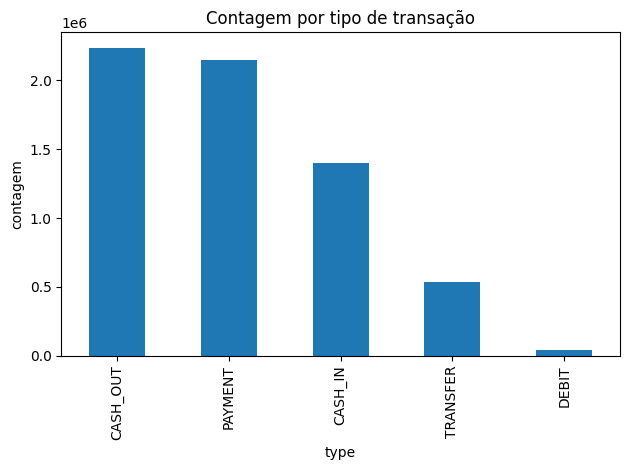


Fraudes: 8,213 de 6,362,620  (taxa ≈ 0.1291%)


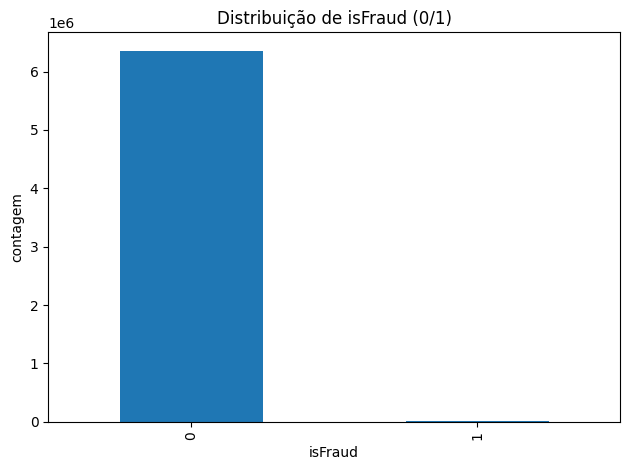

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


,n,fraudes,taxa_fraude
type,,,
TRANSFER,532909,4097,0.0077
CASH_OUT,2237500,4116,0.0018
CASH_IN,1399284,0,0.0000
DEBIT,41432,0,0.0000
PAYMENT,2151495,0,0.0000


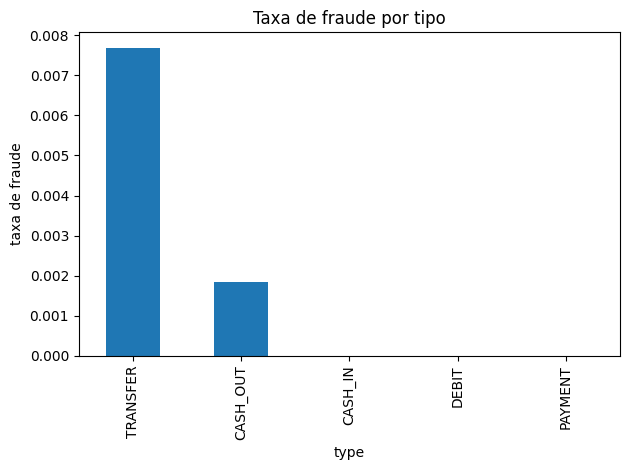

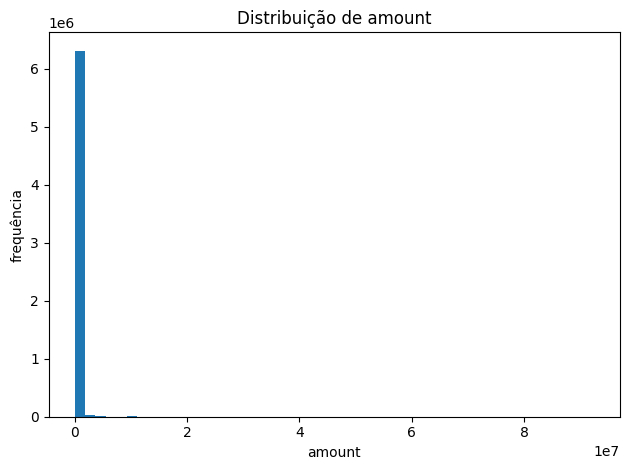

In [5]:

# === 2) Distribuições chave ===

# Contagem por tipo
if "type" in df.columns:
    print("\nContagem por tipo de transação:")
    print(df["type"].value_counts())

    plt.figure()
    df["type"].value_counts().sort_values(ascending=False).plot(kind="bar")
    plt.title("Contagem por tipo de transação")
    plt.xlabel("type")
    plt.ylabel("contagem")
    plt.tight_layout()
    plt.show()

# Fraude geral
if "isFraud" in df.columns:
    fraud_rate = df["isFraud"].mean() if len(df) > 0 else 0.0
    total = len(df)
    print(f"\nFraudes: {df['isFraud'].sum():,} de {total:,}  (taxa ≈ {fraud_rate*100:.4f}%)")

    plt.figure()
    df["isFraud"].value_counts().sort_index().plot(kind="bar")
    plt.title("Distribuição de isFraud (0/1)")
    plt.xlabel("isFraud")
    plt.ylabel("contagem")
    plt.tight_layout()
    plt.show()

# Tabela cruzada: tipo x fraude
if "type" in df.columns and "isFraud" in df.columns:
    xt = pd.crosstab(df["type"], df["isFraud"])
    display(xt)

    # Taxa de fraude por tipo
    grp = df.groupby("type")["isFraud"].agg(["count", "sum", "mean"]).rename(columns={"count": "n", "sum": "fraudes", "mean": "taxa_fraude"})
    display(grp.sort_values("taxa_fraude", ascending=False))

    plt.figure()
    grp["taxa_fraude"].sort_values(ascending=False).plot(kind="bar")
    plt.title("Taxa de fraude por tipo")
    plt.xlabel("type")
    plt.ylabel("taxa de fraude")
    plt.tight_layout()
    plt.show()

# Distribuição de valores (amount)
if "amount" in df.columns:
    plt.figure()
    df["amount"].plot(kind="hist", bins=50)
    plt.title("Distribuição de amount")
    plt.xlabel("amount")
    plt.ylabel("frequência")
    plt.tight_layout()
    plt.show()


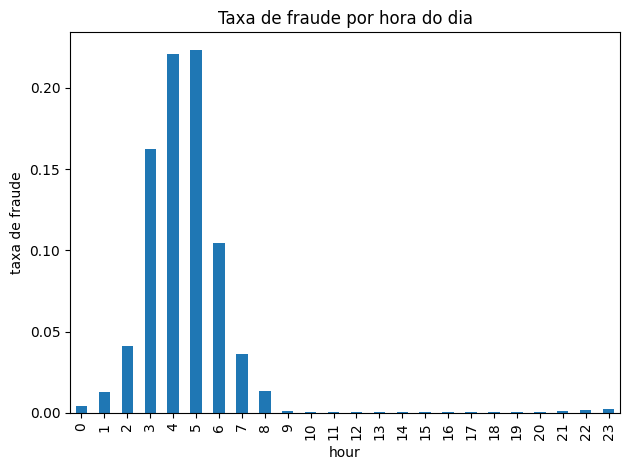

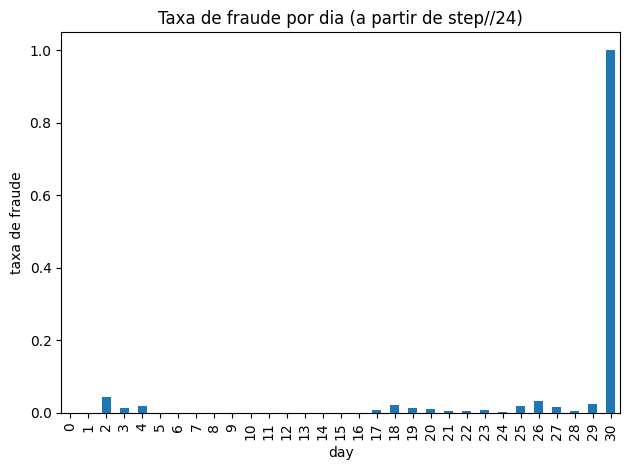

In [6]:

# === 3) Tempo: derivar dia e hora a partir de 'step' (1 step ≈ 1 hora) ===
if "step" in df.columns:
    df["day"] = (df["step"] // 24).astype("int16")
    df["hour"] = (df["step"] % 24).astype("int8")

    if "isFraud" in df.columns:
        by_hour = df.groupby("hour")["isFraud"].mean()
        by_day  = df.groupby("day")["isFraud"].mean()

        plt.figure()
        by_hour.plot(kind="bar")
        plt.title("Taxa de fraude por hora do dia")
        plt.xlabel("hour")
        plt.ylabel("taxa de fraude")
        plt.tight_layout()
        plt.show()

        plt.figure()
        by_day.plot(kind="bar")
        plt.title("Taxa de fraude por dia (a partir de step//24)")
        plt.xlabel("day")
        plt.ylabel("taxa de fraude")
        plt.tight_layout()
        plt.show()


In [7]:

# === 4) Feature Engineering de domínio ===
# Helpers: identificar merchants vs customers (prefixo 'M' no PaySim costuma indicar comerciante)
for col in ["nameOrig", "nameDest"]:
    if col in df.columns and str(df[col].dtype) == "category":
        df[col] = df[col].astype("string")  # facilitar startswith sem explode de memória
        df[col] = df[col].astype("string")

df["orig_is_merchant"] = df["nameOrig"].str.startswith("M").fillna(False).astype("int8") if "nameOrig" in df.columns else 0
df["dest_is_merchant"] = df["nameDest"].str.startswith("M").fillna(False).astype("int8") if "nameDest" in df.columns else 0

# Deltas de balanço e "erros" esperados por tipo
outflow_types = {"CASH_OUT", "TRANSFER", "DEBIT", "PAYMENT"}
inflow_types  = {"CASH_IN"}

def _sign_orig(t):
    if t in outflow_types:
        return -1.0
    elif t in inflow_types:
        return  1.0
    return 0.0

def _sign_dest(t):
    # destino recebe crédito na maioria das transações
    return 1.0

if "type" in df.columns:
    sign_o = df["type"].astype("string").map(_sign_orig).fillna(0.0)
    sign_d = df["type"].astype("string").map(_sign_dest).fillna(0.0)
else:
    sign_o = 0.0
    sign_d = 1.0

for col in ["oldbalanceOrg","newbalanceOrg","oldbalanceDest","newbalanceDest","amount"]:
    if col not in df.columns:
        df[col] = 0.0

df["orig_change"] = (df["newbalanceOrig"] - df["oldbalanceOrg"]).astype("float32")
df["dest_change"] = (df["newbalanceDest"] - df["oldbalanceDest"]).astype("float32")

# Erros de balanço (0 ~ consistente com a regra contábil)
df["errorBalanceOrig"] = (df["oldbalanceOrg"] + sign_o * df["amount"] - df["newbalanceOrig"]).abs().astype("float32")
df["errorBalanceDest"] = (df["newbalanceDest"] - (df["oldbalanceDest"] + sign_d * df["amount"])).abs().astype("float32")

# Indicadores úteis
df["orig_balances_zero"] = ((df["oldbalanceOrg"]==0) & (df["newbalanceOrig"]==0)).astype("int8")
df["dest_balances_zero"] = ((df["oldbalanceDest"]==0) & (df["newbalanceDest"]==0)).astype("int8")

# Transformações
df["log_amount"] = np.log1p(df["amount"]).astype("float32")

# Codificar 'type' de forma compacta (evitar one-hot gigante para baseline)
if "type" in df.columns:
    df["type_code"] = df["type"].astype("category").cat.codes.astype("int8")
else:
    df["type_code"] = 0

# (Opcional) Métricas históricas simples – podem ficar pesadas em 6,3M linhas.
RUN_HEAVY = False  # troque para True se quiser criar estatísticas históricas
if RUN_HEAVY and "nameOrig" in df.columns:
    df["tx_count_by_origin"] = df.groupby("nameOrig")["amount"].transform("size").astype("int32")
    if "nameDest" in df.columns:
        df["tx_count_by_dest"] = df.groupby("nameDest")["amount"].transform("size").astype("int32")


In [8]:

# === 5) O que a regra atual (isFlaggedFraud) captura? ===
if "isFlaggedFraud" in df.columns and "isFraud" in df.columns:
    cm = pd.crosstab(df["isFlaggedFraud"], df["isFraud"], rownames=["isFlaggedFraud"], colnames=["isFraud"])
    print("\nCruzamento isFlaggedFraud x isFraud:")
    display(cm)
    # Cobertura da regra sobre fraudes reais
    if cm.shape == (2,2):
        flagged_recall = (cm.loc[1,1] / (cm[1].sum()+1e-9)) if (cm[1].sum()>0) else 0.0
        print(f"Recall da regra sobre fraudes reais: {flagged_recall:.4f}")



Cruzamento isFlaggedFraud x isFraud:


isFraud,0,1
isFlaggedFraud,,
0,6354407,8197
1,0,16


Recall da regra sobre fraudes reais: 0.0019


Train: (2063665, 11)  Test: (706744, 11)
[LogisticRegression] ROC AUC: 0.9812 | PR AUC: 0.6775


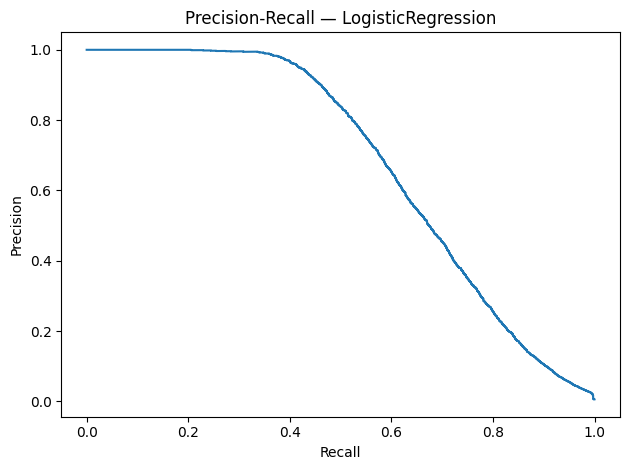

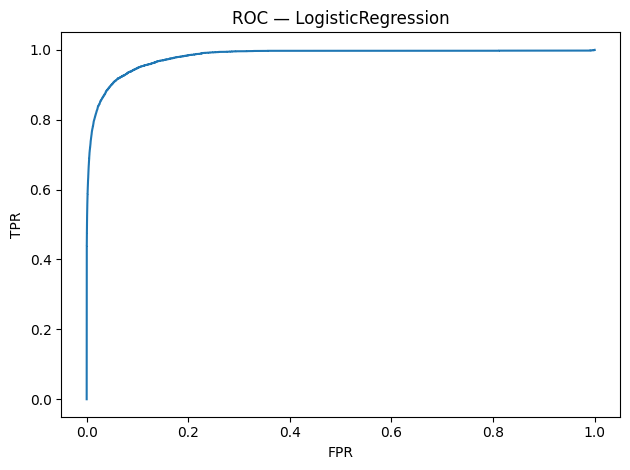

[RandomForest] ROC AUC: 0.9980 | PR AUC: 0.9128


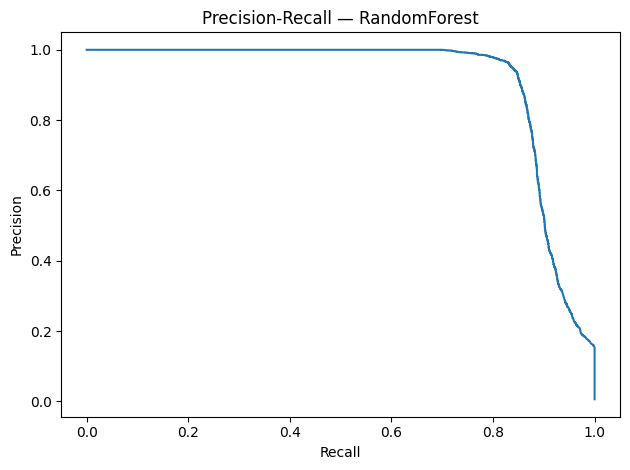

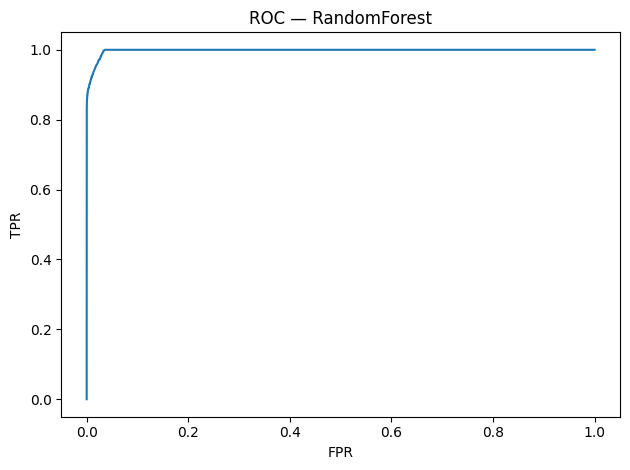

LR threshold p>=0.90 → t=0.9961 (recall≈0.4608)
RF threshold p>=0.90 → t=0.3093 (recall≈0.8533)

[LogReg] Classification report:
              precision    recall  f1-score   support

           0     0.9992    0.9648    0.9817    702258
           1     0.1368    0.8725    0.2365      4486

    accuracy                         0.9642    706744
   macro avg     0.5680    0.9187    0.6091    706744
weighted avg     0.9937    0.9642    0.9770    706744


[RF] Classification report:
              precision    recall  f1-score   support

           0     0.9990    0.9997    0.9993    702258
           1     0.9515    0.8362    0.8901      4486

    accuracy                         0.9987    706744
   macro avg     0.9753    0.9179    0.9447    706744
weighted avg     0.9987    0.9987    0.9986    706744


Matriz de confusão (RF):
[[702067    191]
 [   735   3751]]


In [9]:

# === 6) Split temporal e baseline de modelos ===
FEATURES = ["amount","log_amount","orig_balances_zero","dest_balances_zero",
            "errorBalanceOrig","errorBalanceDest","dest_is_merchant","orig_is_merchant",
            "type_code","hour","day"]

# Focar nos tipos mais relevantes (conforme observado em versões do PaySim)
FOCUS_TYPES = {"TRANSFER","CASH_OUT"}

df_model = df.copy()
if "type" in df_model.columns:
    df_model["type_str"] = df_model["type"].astype("string")
    df_model = df_model[df_model["type_str"].isin(list(FOCUS_TYPES)) | (df_model["isFraud"]==1)]
    df_model.drop(columns=["type_str"], inplace=True)

# Remover linhas com NaN em features (se houver)
df_model = df_model.dropna(subset=[c for c in FEATURES if c in df_model.columns])

if "step" in df_model.columns:
    # split temporal: 75% primeiros steps para treino
    thr = int(df_model["step"].quantile(0.75))
    train_mask = df_model["step"] < thr
else:
    # split aleatório como fallback
    train_mask = np.random.rand(len(df_model)) < 0.75

X = df_model[[c for c in FEATURES if c in df_model.columns]]
y = df_model["isFraud"].astype(int)

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print("Train:", X_train.shape, " Test:", X_test.shape)

# --- Modelo 1: Logistic Regression com ponderação ---
logreg = LogisticRegression(max_iter=200, class_weight="balanced", n_jobs=None, solver="lbfgs")
logreg.fit(X_train, y_train)
proba_lr = logreg.predict_proba(X_test)[:,1]

# --- Modelo 2: RandomForest equilibrado ---
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=2,
    n_jobs=-1,
    class_weight="balanced_subsample",
    random_state=42
)
rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:,1]

def eval_model(y_true, scores, name):
    roc = roc_auc_score(y_true, scores)
    pr  = average_precision_score(y_true, scores)  # PR AUC
    print(f"[{name}] ROC AUC: {roc:.4f} | PR AUC: {pr:.4f}")
    # Curvas
    prec, rec, thr = precision_recall_curve(y_true, scores)
    plt.figure()
    plt.plot(rec, prec)
    plt.title(f"Precision-Recall — {name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.tight_layout()
    plt.show()

    fpr, tpr, thr2 = roc_curve(y_true, scores)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.title(f"ROC — {name}")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.tight_layout()
    plt.show()

eval_model(y_test, proba_lr, "LogisticRegression")
eval_model(y_test, proba_rf, "RandomForest")

# Threshold tuning: buscar maior recall com precision mínima (ex.: 0.90)
def threshold_for_min_precision(y_true, scores, min_precision=0.90):
    prec, rec, thr = precision_recall_curve(y_true, scores)
    best_t = 0.5
    best_rec = 0.0
    for p, r, t in zip(prec[:-1], rec[:-1], thr):
        if p >= min_precision and r > best_rec:
            best_rec = r
            best_t = t
    return best_t, best_rec

t_lr, rec_lr = threshold_for_min_precision(y_test, proba_lr, 0.90)
t_rf, rec_rf = threshold_for_min_precision(y_test, proba_rf, 0.90)
print(f"LR threshold p>=0.90 → t={t_lr:.4f} (recall≈{rec_lr:.4f})")
print(f"RF threshold p>=0.90 → t={t_rf:.4f} (recall≈{rec_rf:.4f})")

# Relatórios (usando threshold padrão 0.5 apenas para referência)
pred_lr = (proba_lr >= 0.5).astype(int)
pred_rf = (proba_rf >= 0.5).astype(int)

print("\n[LogReg] Classification report:")
print(classification_report(y_test, pred_lr, digits=4))

print("\n[RF] Classification report:")
print(classification_report(y_test, pred_rf, digits=4))

print("\nMatriz de confusão (RF):")
print(confusion_matrix(y_test, pred_rf))


err_type
OK    705818
FN       735
FP       191
Name: count, dtype: int64


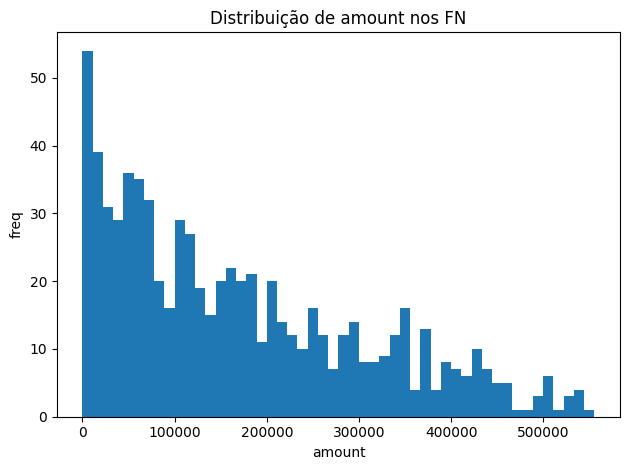

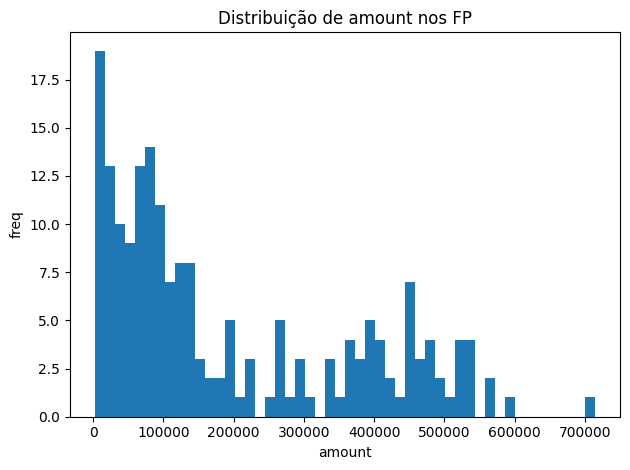

In [10]:

# === 7) Análise rápida de erros ===
# Onde o RF erra? (falsos negativos e falsos positivos)
if len(X_test) > 0:
    errors = df_model.loc[~train_mask, :].copy()
    errors["proba_rf"] = proba_rf
    errors["pred_rf_05"] = (proba_rf >= 0.5).astype(int)
    errors["err_type"] = np.where((errors["isFraud"]==1) & (errors["pred_rf_05"]==0), "FN",
                          np.where((errors["isFraud"]==0) & (errors["pred_rf_05"]==1), "FP", "OK"))
    print(errors["err_type"].value_counts())

    # Distribuição de amount nos erros
    for e in ["FN","FP"]:
        sub = errors[errors["err_type"]==e]
        if len(sub) > 0:
            plt.figure()
            sub["amount"].plot(kind="hist", bins=50)
            plt.title(f"Distribuição de amount nos {e}")
            plt.xlabel("amount")
            plt.ylabel("freq")
            plt.tight_layout()
            plt.show()



## 8) Próximos passos sugeridos
- **Mais features**: janelas temporais (ex.: contagem/valor médio por origem/destino nas últimas 24/48/72h), *velocity features*, e cadeias `TRANSFER → CASH_OUT` por destinatário.
- **Custo do erro**: otimizar *threshold* para reduzir falsos negativos de alto valor (ponderar `amount`).
- **Avaliação**: priorizar **PR AUC** e métricas a partir de *precision-recall* para classes raras.
- **Produção**: monitorar *drift* de taxas e re-treinar periodicamente.
